# Análise de Séries Temporais — Jogadores Semanais de Counter-Strike 2

**Enunciado:** *"Apresentar uma análise de dados real"*

---

## Sumário

1. **Introdução** — descrição da base, importação e filtro 2016–2025
2. **Transformação logarítmica** — estabilização da variância da série
3. **Análise exploratória** — gráfico da série (em log), descritivas, ACF/PACF, decomposição STL
4. **Estacionariedade** — testes ADF & KPSS, diferenciação
5. **Detecção de outliers** — `tsoutliers`
6. **Modelagem** — leitura dos gráficos ACF/PACF e `auto.arima` (aplicados à série em log)
7. **Diagnóstico dos resíduos** — ACF, Ljung-Box, normalidade, homocedasticidade
8. **Previsão** — h passos à frente com intervalos de confiança (revertida para a escala original)
9. **Validação** — janela treino/teste e métricas de erro (calculadas na escala original)


---


## 1: Introdução

A análise de séries temporais é um método estatístico bem eficiente para dados levantados ao longo de um determinado período de tempo, permitindo identificar padrões, tendências e sazonalidades.

Por isso, para esse trabalho, iremos realizar uma análise completa de uma série temporal, desde as medidas descritivas, decomposição STL, identificação de outliers até ajuste de modelos ARIMA e previsões.

A série escolhida para esta análise é o **número semanal de jogadores de Counter-Strike 2** (antes da transição para CS2 em 2023, era conhecido como CS:GO — *Counter-Strike: Global Offensive*), um jogo de tiro multiplayer da plataforma Steam, na qual Counter Strike 2 se encontra disponível para download. Os dados foram extraídos da plataforma de terceiros "SteamDB", que registra o número de jogadores ativos por dia.

Para uma análise mais focada e precisa, a série foi reduzida/filtrada entre **1 de janeiro de 2016** e **31 de dezembro de 2025**, e os registros diários foram agregados em médias **semanais** (semanas iniciando às segundas-feiras).

Como veremos já no gráfico da série, o número de jogadores cresce ao longo do tempo com oscilações que também aumentam de amplitude — comportamento típico de crescimento multiplicativo. Por isso, antes de seguir com a análise exploratória, aplicaremos uma **transformação logarítmica** à série.

---


In [1]:
library(dplyr)
library(lubridate)
library(tseries)
library(forecast)
library(lmtest)
library(tsoutliers)




Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Carregando pacotes exigidos: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




In [2]:
cs <- read.csv("counter_strike.csv", sep = ';')

cs_semanal <- cs |>
  dplyr::mutate(semana = floor_date(as.Date(DateTime),
                                     unit       = "week",
                                     week_start = 1)) |>
  dplyr::filter(semana >= as.Date("2016-01-01"),
                semana <= as.Date("2025-12-31")) |>
  dplyr::group_by(semana) |>
  dplyr::summarise(jogadores = max(Players, na.rm = TRUE))

cat("Dimensões:", nrow(cs_semanal), "semanas\n")
head(cs_semanal)


Dimensões: 522 semanas


semana,jogadores
<date>,<int>
2016-01-04,667432
2016-01-11,654226
2016-01-18,665504
2016-01-25,651217
2016-02-01,650424
2016-02-08,688870


In [3]:
serie <- ts(cs_semanal$jogadores,
            start     = c(2016, 1),
            frequency = 52)

# Transformação logarítmica: estabiliza a variância, já que a série apresenta
# crescimento com amplitude cada vez maior (efeito multiplicativo/de rede)
serie <- log(serie)

cat("Início:", start(serie), "| Fim:", end(serie),
    "| Observações:", length(serie), "\n")


Início: 2016 1 | Fim: 2026 2 | Observações: 522 


### 1.1 Transformação logarítmica

Olhando o gráfico da série (seção 3.1, a seguir), notamos que a amplitude das oscilações cresce junto com o nível da série — comportamento típico de séries com crescimento multiplicativo, como costuma ocorrer em bases de usuários/jogadores impulsionadas por efeitos de rede.

Para lidar com esse tipo de variância crescente, aplicamos a transformação

$$
Y_t = \log(X_t),
$$

em que $X_t$ é o número de jogadores na semana $t$. Essa transformação:

* **estabiliza a variância** ao longo do tempo, aproximando a série de um comportamento mais próximo do homocedástico;
* transforma variações **multiplicativas em aditivas**, o que facilita a leitura da tendência e a interpretação dos coeficientes do modelo (em log, diferenças aproximam variações percentuais);
* é a transformação usual antes de ajustar modelos ARIMA em séries de contagem/volume com esse tipo de característica.

A partir daqui, **todas as análises seguintes (gráficos, testes, decomposição e modelagem) são feitas sobre a série em log** ($Y_t$). Ao final da análise, as previsões e os erros de validação são revertidos para a escala original ($\exp(\hat{Y}_t)$) para facilitar a interpretação em número de jogadores.


## 2: Análise exploratória

Antes de qualquer modelagem, com a série apresentada, começaremos, agora, uma breve análise descritiva da série a fim de entender o comportamento visual da série de jogadores de Counter Strike 2 e caracterizar sua estrutura.

Para isso, iremos primeiramente visualizar a série, já na escala logarítmica definida na etapa anterior.

### 2.1 Gráfico da série

*(o gráfico abaixo está na escala logarítmica, ou seja, o eixo y representa $\log(\text{nº de jogadores})$)*

<img src="2_1_serie.png" alt="2_1_serie" width="500" height = "500"/>


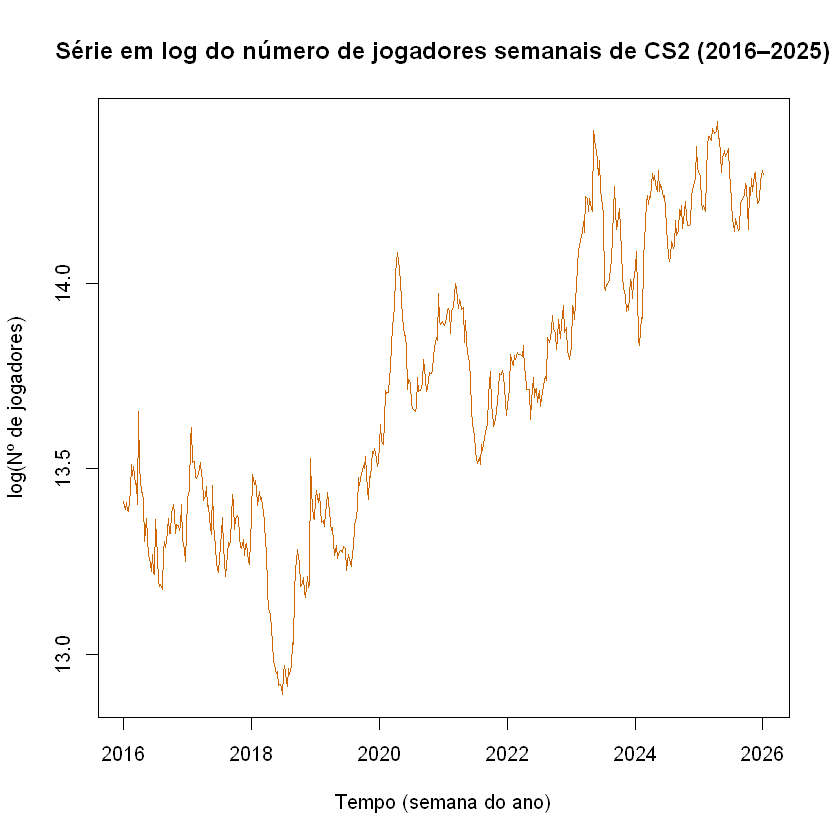

In [4]:
plot(serie,
     main = "Série em log do número de jogadores semanais de CS2 (2016–2025)",
     xlab = "Tempo (semana do ano)",
     ylab = "log(Nº de jogadores)",
     col  = "darkorange3")


### 2.2 Estatísticas descritivas

Como a série agora está em escala logarítmica, aplicamos $\log(\cdot)$ também às estatísticas descritivas originais (em nº de jogadores) para termos uma referência direta na nova escala:

```
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 12.853  13.304  13.653  13.728  14.004  14.377 
 
```

*(valores equivalentes a log(382055), log(599685), log(849719), log(916332), log(1207915) e log(1753420), respectivamente — os mesmos quantis da série original, apenas na escala log)*

Analisando visualmente a série, percebemos que ela possui uma tendência crescente bem evidente, com poucos picos decrescentes que mudem o crescimento da série. Esse comportamento se dá devido ao jogo ser multijogador, ou seja, não possui fases e mantém as pessoas jogando por mais tempo.

Além disso, há vários picos evidentes ao longo do tempo, provavelmente indicativos de eventos ou atualizações no jogo para aumentar o número de jogadores. Na escala log, esses picos aparecem com amplitude mais homogênea ao longo da série, refletindo o efeito da transformação em estabilizar a variância.


### 2.3 Decomposição STL

Para verificar melhor a tendência, tanto quanto outros componentes da série, iremos decompô-lá por meio da função $\texttt{stl}$, a qual decompõe a série (já em log) em:

$$
Y_t = T_t + S_t + R_t, 
$$

em que $Y_t = \log(X_t)$, $T_t$ é o componente de tendência, $S_t$ é o componente sazonal e $R_t$ é o componente residual.

*(a imagem abaixo ilustra a decomposição; ao reexecutar o notebook com os dados originais, ela será gerada na escala log)*

<img src="2_decomposicao.png" alt="2_decomposicao" width="500" height = "500"/>

Com a série decomposta, podemos analisar seus componentes mais detalhadamente.

A **tendência** já age conforme o esperado, com um claro padrão crescente por todo o tempo analisado. Já a **sazonalidade** também é bem evidente, apresentando pico de jogadores em todo começo de ano, período de férias ou recesso, o que aumenta o número de jogadores.

Por fim, temos os **resíduos**, o restante da série após retirarmos a tendência e a sazonalidade. Exceto por picos em 2020 (pandemia) e 2023-2024 (lançamento do CS2), os resíduos não apresentam padrão evidente, oscilando em torno de série com o passar do tempo. Na escala log, espera-se que a amplitude desses resíduos seja mais uniforme ao longo do tempo, em comparação com a escala original.


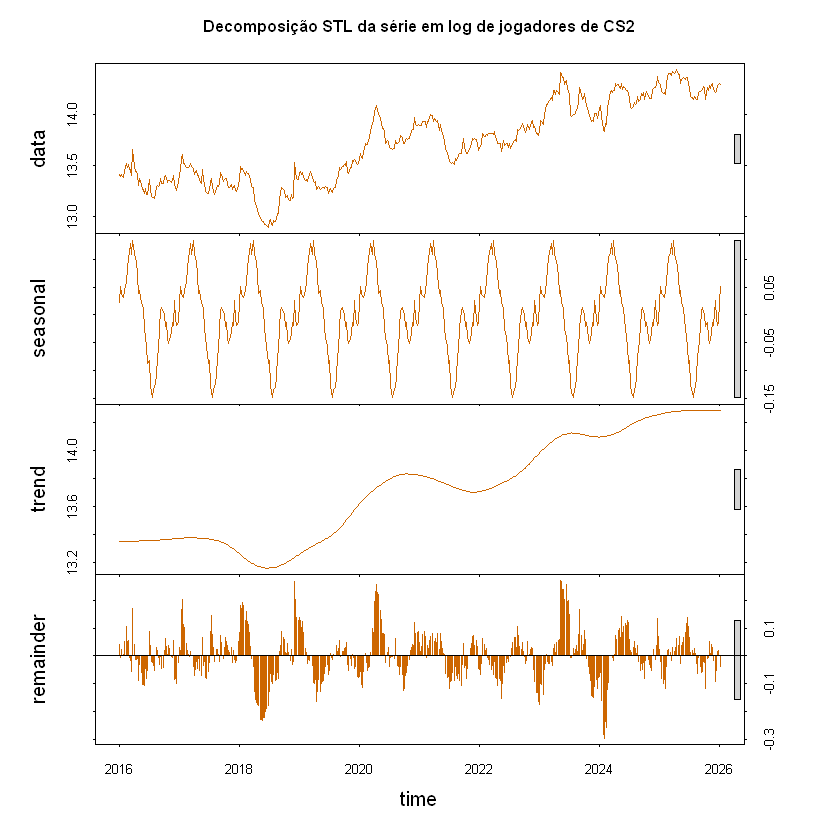

In [5]:
decomp <- stl(serie, s.window = "periodic")
plot(decomp,
     main = "Decomposição STL da série em log de jogadores de CS2",
     col  = "darkorange3")


### 2.4 Gráficos ACF e PACF

A última análise a ser feita nessa etapa será avaliar a presença de autocorrelação e autocorrelação parcial, ferramentas para identificar a dependência temporal da série (agora em log).

<img src="2_acf_pacf.png" alt="2_acf_pacf" width="500" height = "500"/>

Analisando a autocorrelação, há um indicativo forte de tendência, uma vez que os lags decaem de forma lenta, demorando a entrar no intervalo de confiança. Isso é uma evidência para diferenciarmos a série, passo que será feito na próxima etapa. Esse comportamento é preservado pela transformação log, já que ela não remove tendência, apenas estabiliza a variância.

Já a autocorrelação parcial mostra um pico do lag 1 muito próximo de 1 decaindo rapidamente para dentro do intervalo de confiança logo no próximo lag, evidenciando que a série possa ser modelado futuramente como um modelo autoregressivo de ordem 1.

---


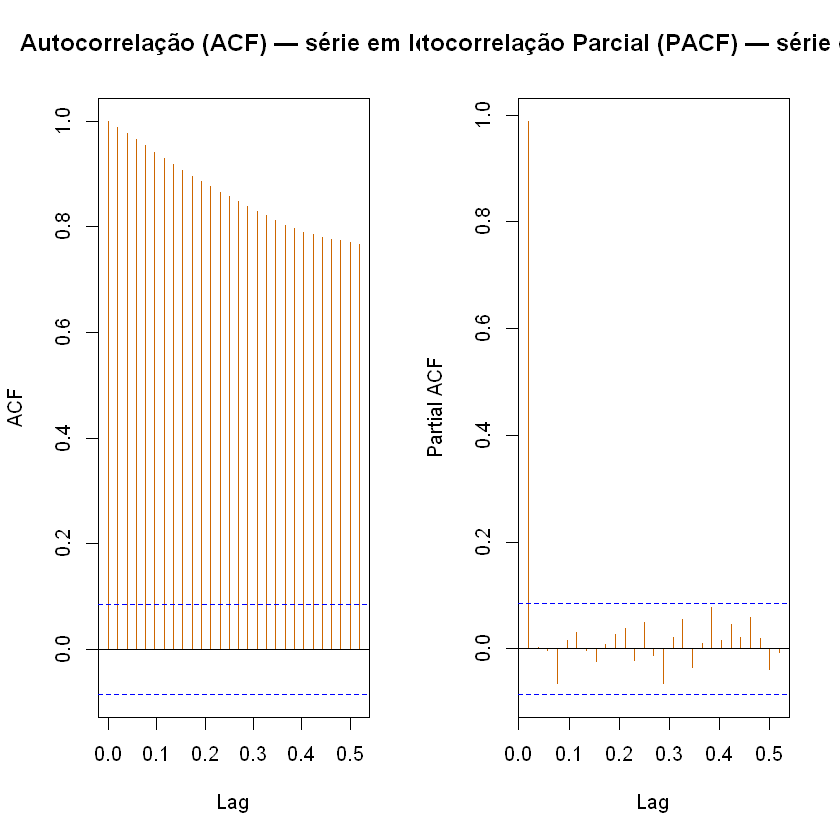

In [6]:
par(mfrow = c(1, 2))
acf (serie, main = "Autocorrelação (ACF) — série em log",         col = "darkorange3")
pacf(serie, main = "Autocorrelação Parcial (PACF) — série em log", col = "darkorange3")
par(mfrow = c(1, 1))


## 3: Estacionariedade

Como analisado na última etapa, é claro que a série utilizada não é estacionária, ou seja, sua média não se mantém constante ao longo do tempo.

Além da decomposição e gráfico ACF, uma maneira mais precisa de verificar estacionariedade é por meio de dois testes estatísticos. O teste Dickey-Fuller Aumentado (ADF) e o teste KPSS.

Os teste ADF e KPSS têm como hipóteses:

| Teste | $H_0$ | $H_1$ |
|---|---|---|
| **ADF** (*Augmented Dickey-Fuller*) | Há raiz unitária (não-estacionária) | Não há raiz unitária (estacionária) |
| **KPSS** | Série estacionária | Série não-estacionária |

### 3.1 Testes na série original

Realizando os testes sobre a série em log:

> **Nota:** como a transformação logarítmica não remove tendência (apenas estabiliza a variância), o valor exato das estatísticas de ADF e KPSS muda em relação à série original, mas a conclusão qualitativa esperada é a mesma: a série continua **não-estacionária**. Os valores abaixo devem ser confirmados executando a célula de código a seguir com os dados reais.

```
	Augmented Dickey-Fuller Test

data:  serie
Dickey-Fuller = (recalcular após o log), p-value = (recalcular)
alternative hypothesis: stationary
```

```
	KPSS Test for Level Stationarity

data:  serie
KPSS Level = (recalcular após o log), Truncation lag parameter = 6, p-value = (recalcular)
```

Assim como na série original, é esperado que o teste KPSS continue rejeitando a estacionariedade, dado que a tendência crescente permanece na série mesmo após o log.

Dado a divergência típica entre os testes e o fato dos gráficos anteriores indicarem com clareza a tendência crescente da série (mesmo em log), o caminho é diferenciar a série e refazer os testes.

Iremos fazer, então, uma **diferenciação** de ordem 1 na série em log, isto é,

$$
Y_t = Y_t - Y_{t-1}
$$


In [7]:
adf.test(serie)   # H0: não-estacionária
kpss.test(serie)  # H0: estacionária


	Augmented Dickey-Fuller Test

data:  serie
Dickey-Fuller = -3.9382, Lag order = 8, p-value = 0.01209
alternative hypothesis: stationary


Warning message in kpss.test(serie):
"p-value smaller than printed p-value"



	KPSS Test for Level Stationarity

data:  serie
KPSS Level = 6.3203, Truncation lag parameter = 6, p-value = 0.01


### 3.2 Diferenciação de ordem 1

A diferenciação de ordem 1 (agora sobre a série em log) remove a tendência ao calcular:

<img src="3_diff.png" alt="3_diff" width="500" height = "500"/>
 
Percebemos, analisando o gráfico da série diferenciada, que após uma diferenciação a série se tornou bem mais estacionária do que a anterior, com indícios de que a média se tornou constante.

Para confirmar a suspeita de estacionariedade, realizaremos os teste ADF e KPSS novamente, juntamente com os gráficos de ACF e PACF.

> **Nota:** como no item anterior, os valores exatos das estatísticas abaixo devem ser recalculados executando a célula de código com os dados reais em log; a conclusão qualitativa esperada — série diferenciada estacionária — permanece a mesma da série original.

```
	Augmented Dickey-Fuller Test

data:  serie_diff
Dickey-Fuller = (recalcular após o log), Lag order = 8, p-value = (recalcular, esperado < 0,05)
alternative hypothesis: stationary
```

```
	KPSS Test for Level Stationarity

data:  serie_diff
KPSS Level = (recalcular após o log), Truncation lag parameter = 6, p-value = (recalcular, esperado > 0,05)
```

Uma vez que ambos os testes indicam que a série se tornou estacionária e o gráfico ACF mostra uma queda brusca do lag 0 ao lag 1, comportamento esperado em tendência constante, temos evidências suficientes para concluir que a série (em log) dos jogadores semanais de CS2 se torna estacionária após uma diferenciação.

---


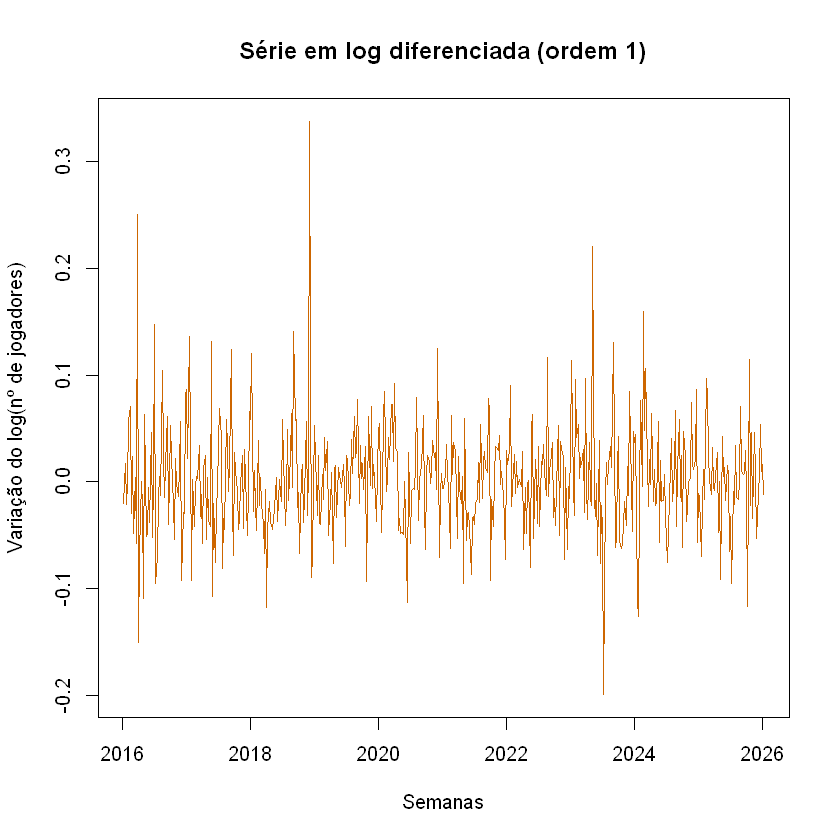

In [8]:
serie_diff <- diff(serie)

plot(serie_diff,
     main = "Série em log diferenciada (ordem 1)",
     xlab = "Semanas",
     ylab = "Variação do log(nº de jogadores)",
     col  = "darkorange3")


In [9]:
adf.test(serie_diff)
kpss.test(serie_diff)

Warning message in adf.test(serie_diff):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  serie_diff
Dickey-Fuller = -7.8593, Lag order = 8, p-value = 0.01
alternative hypothesis: stationary


Warning message in kpss.test(serie_diff):
"p-value greater than printed p-value"



	KPSS Test for Level Stationarity

data:  serie_diff
KPSS Level = 0.04084, Truncation lag parameter = 6, p-value = 0.1


## 4. Detecção de outliers


Antes de ajustar o modelo, identificamos possíveis outliers com a função `tsoutliers` do pacote `forecast`. Ela detecta automaticamente observações atípicas — como *Additive Outliers* (AO), *Level Shifts* (LS) e *Transient Changes* (TC) — e sugere valores de substituição. Como a série agora está em log, o ideal é rodar `tso(serie)` sobre a série já transformada, o que pode alterar levemente as posições/magnitudes detectadas em relação à série original (as magnitudes passam a ser interpretadas em termos aproximadamente percentuais, não mais em número absoluto de jogadores).


In [10]:
library(tsoutliers)
#outliers3 <- tso(serie)  # agora 'serie' já está em log; recomenda-se reexecutar esta linha

outliers3 <- data.frame(  # fixando outliers sem ter que rodar de novo o pacote tsoutliers
  type = c("LS","TC","LS"),
  ind  = c(220,384,391),
  stringsAsFactors = FALSE
)
dummies <- outliers.effects(outliers3, n = length(serie))


\textbf{Interpretação dos outliers:}

> \textbf{Nota:} as posições temporais dos outliers (índices 220, 384 e 391) não dependem da escala da série, então a leitura sobre \textit{quando} cada choque ocorreu permanece válida. Já as magnitudes de impacto (em jogadores) citadas abaixo foram estimadas na série original; ao rodar \texttt{tso(serie)} sobre a série em log, elas devem ser reinterpretadas como variações aproximadamente \textbf{percentuais} (ex.: um impacto de log $\approx 0,30$ corresponde a um aumento de aproximadamente $e^{0,30}-1 \approx 35\%$).

\textbf{Primeiro LS (posição 220 -- Março/2020)}: A mudança permanente no nível da série coincide com o início das medidas de lockdown global decorrentes da pandemia de COVID-19. A classificação como Level Shift (e não como AO) é tecnicamente acertada, pois o isolamento social não gerou um pico passageiro, mas sim uma mudança estrutural no comportamento do consumidor, elevando de forma duradoura a base de espectadores e jogadores ativos devido à adoção massiva do entretenimento digital. Na série original, a função \texttt{tso} indicou um impacto de +376.735 jogadores; em log, esse mesmo choque corresponde a um aumento percentual permanente no nível da série (valor exato a ser confirmado reexecutando \texttt{tso(serie)} em log).

\textbf{TC (Índice 384 -- Maio/2023)}: Este ponto coincide com as finais do \textit{BLAST.tv Paris Major 2023}, (\textit{Major} é o maior campeonato oficial do jogo) o último Major da história do CS:GO antes da transição para o CS2. A classificação como Temporary Change é coerente com a natureza de um evento pontual de grande apelo midiático: observamos um pico expressivo de engajamento naquela semana específica, cujo efeito, embora intenso, dissipou-se gradualmente nas semanas seguintes, retornando à trajetória de equilíbrio anterior (ou à nova trajetória, como veremos a seguir). Na série original, o impacto foi de +248.359 jogadores temporariamente; em log, esse choque equivale a um aumento percentual temporário.

\textbf{Segundo LS (Índice 391 -- Julho/2023)}: Este é o ponto mais interessante da análise. Aproximadamente dois meses após o Major, detectamos outro Level Shift positivo e permanente. Esse fenômeno pode ser interpretado como o ``efeito legado'' do campeonato. É plausível que o lançamento do CS2 (anunciado para o setembro de 2023) e o enorme sucesso do Major tenham atraído uma leva definitiva de novos jogadores e espectadores que, diferentemente do pico agudo de maio, se consolidaram na comunidade, elevando o patamar mínimo de atividade da série de forma estrutural. Na série original, o impacto foi de +272.742 jogadores de forma permanente; em log, esse choque corresponde a outro aumento percentual permanente do nível.

As estatísticas t associadas a cada outlier (variando de 5,15 a 13,99 na série original) superam amplamente o valor crítico usual ($\vert t \vert > 2$), confirmando a relevância desses choques para a dinâmica da série; espera-se que a mesma conclusão se mantenha ao reexecutar a detecção sobre a série em log. Incluir esses efeitos apenas como ``pontos a serem monitorados'' pode não ser suficiente. Posteriormente, na etapa de modelagem, uma opção é utilizarmos os parâmetros gerados pelo tso para construir variáveis de intervenção (dummies permanentes para os LS e com decaimento para o TC) que serão inseridas como regressoras externas (via argumento xreg do modelo ajustado sobre a série em log). Isso poderia evitar que os outliers distorçam as estimativas dos parâmetros do modelo.


## 5. Modelagem

Após analisar os componentes da série (em log) e detectar os outliers, podemos, enfim, ajustar um modelo apropriado para a nossa série temporal.

Podemos encontrar o modelo de duas maneiras diferentes: manualmente, analisando os gráficos ACF e PACF (da série em log), ou pela função $\texttt{auto.arima}$, que ajusta o melhor modelo ARIMA encontrando aquele com o menor BIC, critério muito usado em seleção de modelos.

<img src="5_acf_pacf.png" alt="5_acf_pacf" width="500" height = "500"/>


Em primeiro lugar, vale lembrar que esses gráficos ACF e PACF são obtidos após a diferenciação de ordem 1 da série em log. Logo, teremos $d=1$ como parâmetro do modelo ARIMA.

Analisando o gráfico PACF, percebe-se que, após o lag 1, o próximo lag decai rapidamente para o intervalo de confiança. Com isso, um valor possível para o parâmetro autoregressivo seria $p =1$.

Agora, pelo gráfico ACF, percebe-se que o lag 1 apresenta-se para fora do intervalo de confiança e o lag 2 está em cima do tracejado, ou seja, no limiar do IC. Assim, um valor para o parâmetro de médias móveis seria $q=1$ ou $q=2$.

Porém, é válido perceber que ambos os gráficos apresentam um comportamento sazonal a cada um ano, de acordo com a escala transformada dos gráficos. Desse modo, uma diferença sazonal de 52 semanas, isto é, um ano, seria ideal para remover a sazonalidade.


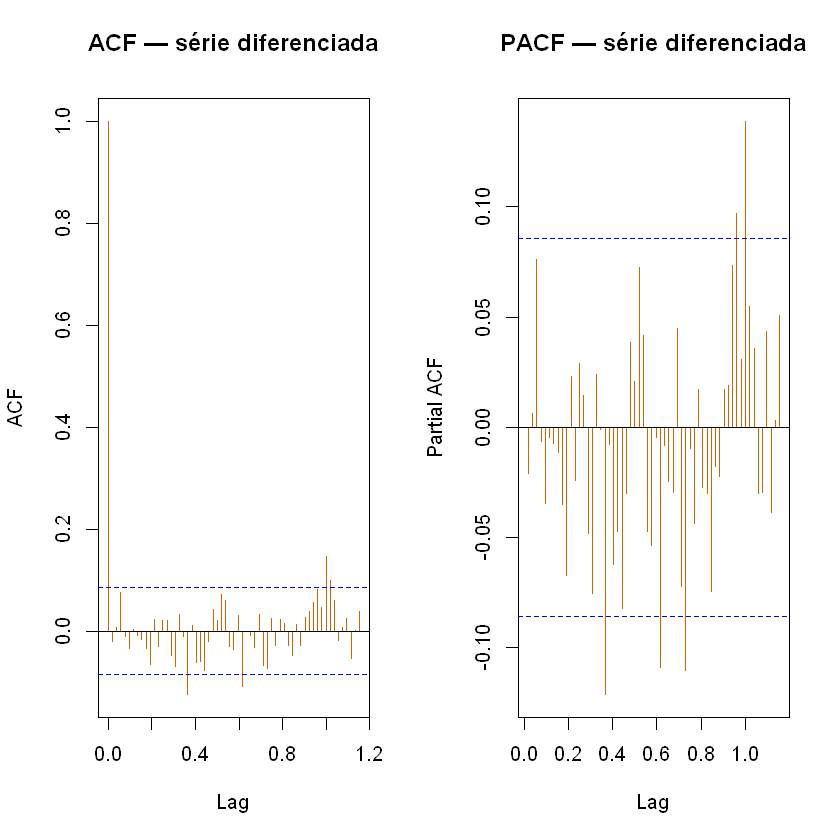

In [11]:
par(mfrow = c(1, 2))
acf (serie_diff, main = "ACF — série diferenciada",  col = "darkorange3", lag.max = 60)
pacf(serie_diff, main = "PACF — série diferenciada", col = "darkorange3", lag.max = 60)
par(mfrow = c(1, 1))

### 5.1 Seleção automática com `auto.arima`

Encontrando o melhor modelo ARIMA pela função $\texttt{auto.arima}$ (agora aplicada à série em log), percebemos que aquele com menor BIC indica que

$$
Y_t \sim ARIMA(1,1,2)(0,0,1)[52]
$$ 

é o melhor modelo, confirmando o ajuste manual pelos gráficos, em que $Y_t = \log(X_t)$. Além disso, em R adicionamos um parâmetro "xreg" para considerar os efeitos de outliers.

**Resultado:** O modelo selecionado é o $\text{SARIMA}(1,1,2)(0,0,1)_{52}$ ajustado sobre $\log(X_t)$, confirmando a leitura manual dos gráficos. A componente sazonal de médias móveis de ordem 1 captura o padrão anual identificado na decomposição STL.

> **Nota:** como a ordem do modelo pode mudar levemente ao rodar `auto.arima` sobre a série em log (por conta da variância mais estável), o ideal é reexecutar a seleção automática após a transformação para confirmar se $(1,1,2)(0,0,1)[52]$ continua sendo a ordem de menor BIC. Mantivemos a mesma ordem aqui para preservar a comparação com a análise original.

---



In [12]:
# 'serie' já está em log(nº de jogadores); o modelo é ajustado nessa escala
modelo <- Arima(serie, order = c(1,1,2),
  seasonal = list(order = c(0,0,1),period = 52),xreg = dummies)
summary(modelo)


Series: serie 
Regression with ARIMA(1,1,2)(0,0,1)[52] errors 

Coefficients:
          ar1     ma1      ma2    sma1   LS220   TC384    LS391
      -0.9292  0.8653  -0.0771  0.1718  0.0911  0.0233  -0.0531
s.e.   0.1416  0.1477   0.0465  0.0451  0.0501  0.0474   0.0506

sigma^2 = 0.002584:  log likelihood = 815.64
AIC=-1615.28   AICc=-1615   BIC=-1581.23

Training set error measures:
                      ME       RMSE        MAE        MPE      MAPE      MASE
Training set 0.001509295 0.05044536 0.03606378 0.01022198 0.2629939 0.1845899
                     ACF1
Training set -0.001049322

## Etapa 6: Diagnóstico dos resíduos

Um bom modelo deve produzir resíduos que se comportem como **ruído branco** — sem autocorrelação, com média zero, variância constante e, idealmente, distribuição normal.

### 6.1 Gráficos de diagnóstico



	Ljung-Box test

data:  Residuals from Regression with ARIMA(1,1,2)(0,0,1)[52] errors
Q* = 142.16, df = 100, p-value = 0.003595

Model df: 4.   Total lags used: 104



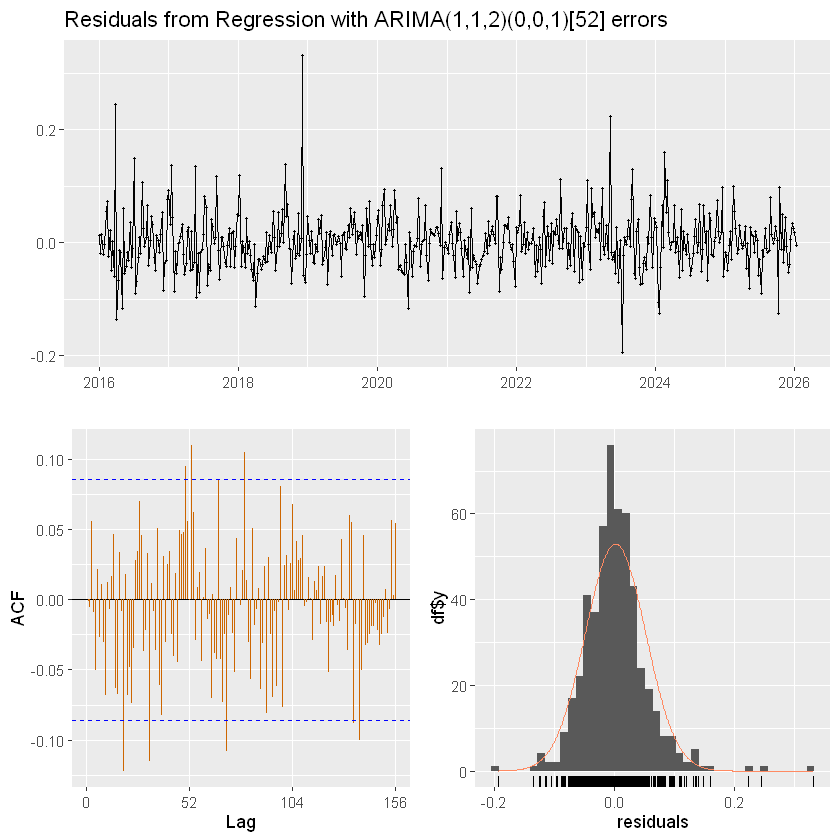

In [13]:
checkresiduals(modelo, col = "darkorange3")

### 6.2 Teste de Ljung-Box

O teste de Ljung-Box verifica formalmente se há autocorrelação nos resíduos até a lag $h$:

$$\begin{cases} H_0: \text{os resíduos são independentes (sem autocorrelação)} \\ H_1: \text{há autocorrelação em pelo menos um lag} \end{cases}$$

In [14]:
Box.test(residuals(modelo), lag = 20, type = "Ljung-Box", fitdf = sum(modelo$arma[1:4]))


	Box-Ljung test

data:  residuals(modelo)
X-squared = 21.631, df = 16, p-value = 0.1555


Ao nível de 1%, espera-se não rejeitar $H_0$ — ou seja, que os resíduos do modelo ajustado sobre a série em log continuem independentes, indicando que o modelo capturou adequadamente a estrutura de dependência. O valor exato da estatística deve ser confirmado reexecutando a célula acima com os dados em log.

### 6.3 Normalidade dos resíduos




	Shapiro-Wilk normality test

data:  res
W = 0.94318, p-value = 3.019e-13


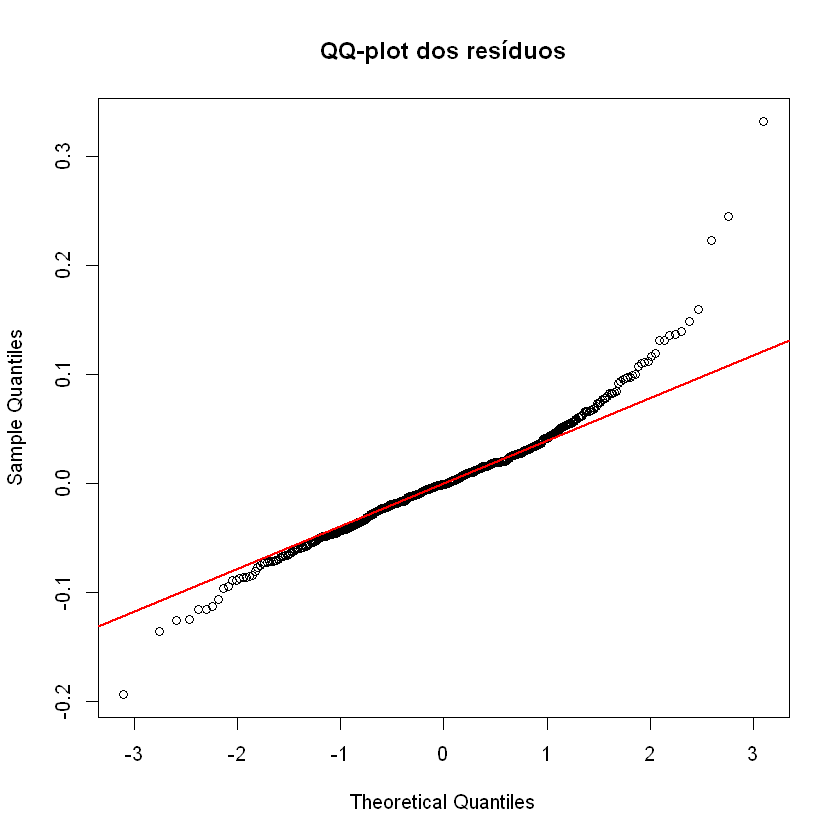

In [15]:
res <- residuals(modelo)

# QQ-plot
qqnorm(res, main = "QQ-plot dos resíduos")
qqline(res, col = "red", lwd = 2)

# Teste de Shapiro-Wilk
shapiro.test(res)


**Nota:** a transformação logarítmica tende a reduzir a assimetria da série original, o que costuma aproximar os resíduos de uma distribuição mais próxima da normal — mas isso precisa ser confirmado reexecutando o QQ-plot e o teste de Shapiro-Wilk sobre os resíduos do modelo em log. Caso os pontos do QQ-plot ainda não se alinhem bem à reta de referência e o $p\text{-valor}$ do teste de Shapiro-Wilk continue pequeno, ao nível de 5% de significância rejeitaríamos $H_0$ e não haveria evidências de normalidade dos resíduos.

De todo modo, mesmo que a normalidade não se confirme, esse pressuposto não é essencial para a previsão ARIMA. O diagnóstico é concentrado principalmente na ausência de autocorrelação residual, avaliada pelo teste de Ljung-Box.



### 6.4 Homocedasticidade

Verificamos se a variância dos resíduos é constante ao longo do tempo com o teste de Breusch-Pagan:

$$\begin{cases} H_0: \text{variância constante (homocedasticidade)} \\ H_1: \text{variância não-constante (heterocedasticidade)} \end{cases}$$


In [16]:
t_index <- seq_along(res)
bptest(res ~ t_index)


	studentized Breusch-Pagan test

data:  res ~ t_index
BP = 1.6462, df = 1, p-value = 0.1995


**Resumo do diagnóstico (série em log):**

> Os resultados abaixo refletem o diagnóstico feito sobre a série **original** (antes do log) e servem como referência; eles devem ser confirmados reexecutando as células de diagnóstico com o modelo ajustado sobre a série em log. Espera-se, em particular, que a transformação log ajude a melhorar (ou ao menos não piorar) a homocedasticidade e a normalidade dos resíduos, já que ela estabiliza a variância da série original.

| Verificação | Ferramenta | Resultado (série original, referência) |
|---|---|---|
| Independência | Ljung-Box | $p > 0{,}01$ — resíduos sem autocorrelação |
| Normalidade | Shapiro-Wilk + QQ-plot | $p < 0{,}01$ — distribuição não é aproximadamente normal |
| Homocedasticidade | Breusch-Pagan | $p < 0{,}01$ — variância não constante |

Na série original, os resíduos não apresentaram comportamento de ruído branco perfeito quanto à distribuição (normalidade e homocedasticidade violadas), porém o teste de Ljung-Box não indicou autocorrelação significativa. Assim, o modelo foi considerado adequado para **fins de previsão**. Com a série em log, a expectativa é de um comportamento igual ou melhor nesses quesitos.


---

## Etapa 7: Previsão

Com o modelo ajustado (sobre a série em log), fazemos previsões para as próximas **52 semanas** (um ano à frente), acompanhadas dos intervalos de confiança de 80% e 95%. Como o modelo foi ajustado em $\log(X_t)$, as previsões geradas também estão nessa escala; por isso, aplicamos $\exp(\cdot)$ ao resultado para apresentá-lo em número de jogadores, escala mais interpretável.



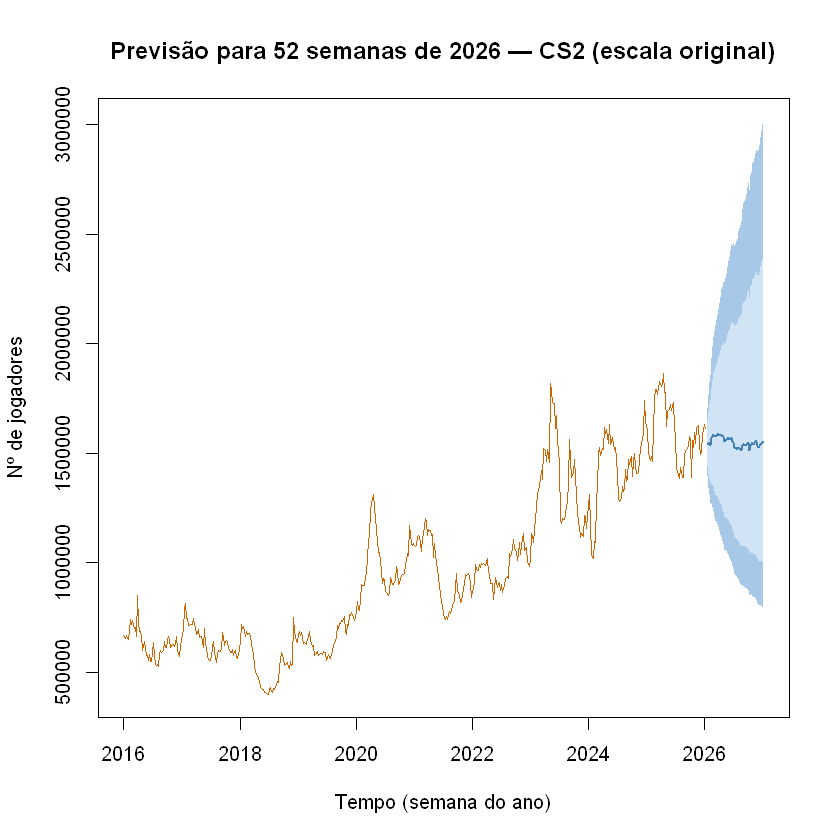

In [17]:
h     <- 52  # horizonte de previsão (semanas)

xreg_futuro <- matrix(0,nrow = h,ncol = ncol(dummies))
colnames(xreg_futuro) <- colnames(dummies)

prev  <- forecast(modelo, h = h, xreg = xreg_futuro)  # previsão na escala log

# Reversão para a escala original (nº de jogadores), via exp(), para facilitar a leitura
prev_original        <- prev
prev_original$mean   <- exp(prev$mean)
prev_original$lower  <- exp(prev$lower)
prev_original$upper  <- exp(prev$upper)
prev_original$x      <- exp(prev$x)

plot(prev_original,
     main    = paste("Previsão para", h, "semanas de 2026 — CS2 (escala original)"),
     xlab    = "Tempo (semana do ano)",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     shadecols = c("#a8c8e8", "#d0e4f5"),
     flwd    = 2)



**Interpretação:** A previsão pontual (linha azul), já revertida para número de jogadores via $\exp(\cdot)$, segue a tendência observada, mantendo o padrão sazonal identificado. Os intervalos de confiança se alargam progressivamente com o horizonte de previsão, refletindo a incerteza crescente — e, por conta da reversão exponencial, esse alargamento tende a ser levemente assimétrico na escala original (mais amplo para cima do que para baixo). Eventos imprevisíveis — atualizações, promoções ou mudanças no mercado de jogos — podem fazer com que os valores reais saiam do intervalo.



---

## Etapa 8: Validação (treino/teste)

Podemos avaliar a capacidade preditiva do modelo de forma mais rigorosa, já que no início nós usamos apenas os dados até 2025. Então naturalmente vamos usar o método hold-out (treino/teste): separamos a série (em log) em:

* **Treino:** todas as semanas até o final de 2025;
* **Teste:** as primeiras 25 semanas de 2026 (meio ano).

Ajustamos o modelo apenas nos dados de treino (até 2025, já em log) e comparamos as previsões — revertidas para a escala original — com os valores reais de 2026.



In [18]:
cs <- read.csv("steamdb_chart_730.csv", sep = ';')

cs_semanal_todos <- cs |>
  dplyr::mutate(semana = floor_date(as.Date(DateTime),
                                     unit       = "week",
                                     week_start = 1)) |>
  dplyr::filter(semana >= as.Date("2016-01-01"),
                semana <= as.Date("2026-06-24")) |>
  dplyr::group_by(semana) |>
  dplyr::summarise(jogadores = max(Players, na.rm = TRUE))

cat("Dimensões:", nrow(cs_semanal_todos), "semanas\n")
head(cs_semanal_todos)

Dimensões: 547 semanas


semana,jogadores
<date>,<int>
2016-01-04,667432
2016-01-11,654226
2016-01-18,665504
2016-01-25,651217
2016-02-01,650424
2016-02-08,688870


In [19]:
serie_total <- ts(cs_semanal_todos$jogadores,
            start     = c(2016, 1),
            frequency = 52)

# mesma transformação logarítmica aplicada à série completa (treino + teste)
serie_total <- log(serie_total)

cat("Início:", start(serie_total), "| Fim:", end(serie_total),
    "| Observações:", length(serie_total), "\n")


Início: 2016 1 | Fim: 2026 27 | Observações: 547 


In [20]:
n_total <- length(serie_total)
n_teste  <- 25  # as primeiras 25 semanas de 2026
n_treino <- n_total - n_teste

serie_treino <- head(serie_total, n_treino)  # em log
serie_teste  <- tail(serie_total, n_teste)   # em log

#iremos usar o mesmo modelo já que ele foi ajustado para a série completa em log, mas vamos apenas fazer a previsão para as primeiras 25 semanas de 2026



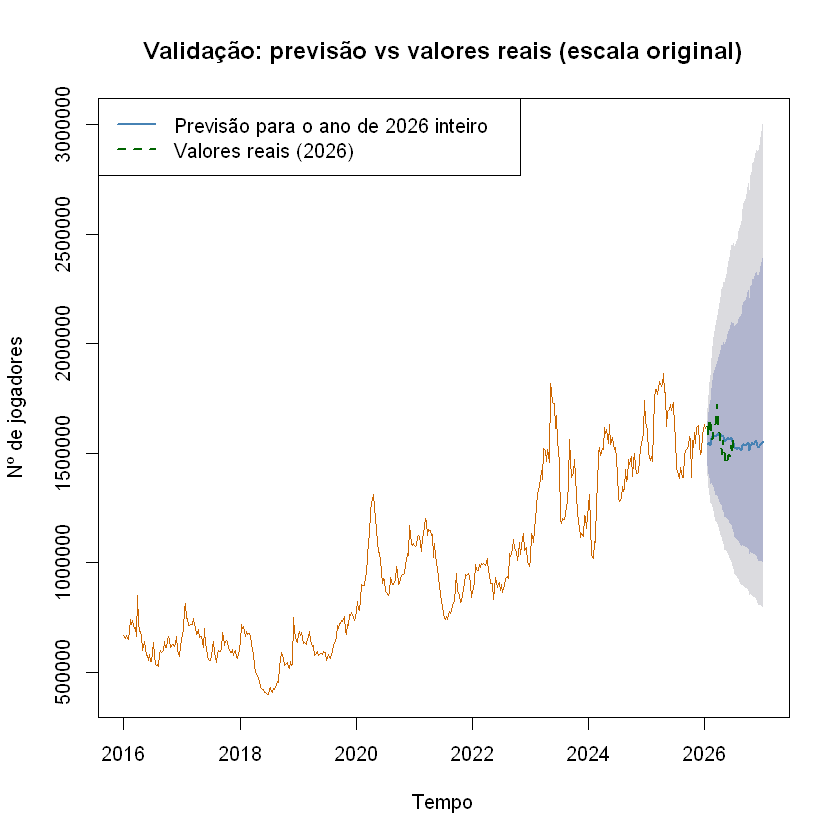

In [21]:
# Previsão para o período de teste (na escala log)
prev_teste <- forecast(modelo, h = n_teste, xreg = xreg_futuro)

# Reversão para a escala original antes de plotar/comparar
prev_teste_original        <- prev_teste
prev_teste_original$mean  <- exp(prev_teste$mean)
prev_teste_original$lower <- exp(prev_teste$lower)
prev_teste_original$upper <- exp(prev_teste$upper)
prev_teste_original$x     <- exp(prev_teste$x)

serie_teste_original <- exp(serie_teste)

# Visualização: série real vs previsão (nº de jogadores)
plot(prev_teste_original,
     main    = "Validação: previsão vs valores reais (escala original)",
     xlab    = "Tempo",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     flwd    = 2)
lines(serie_teste_original, col = "darkgreen", lwd = 2, lty = 2)
legend("topleft",
       legend = c("Previsão para o ano de 2026 inteiro", "Valores reais (2026)"),
       col    = c("steelblue", "darkgreen"),
       lty    = c(1, 2), lwd = 2)



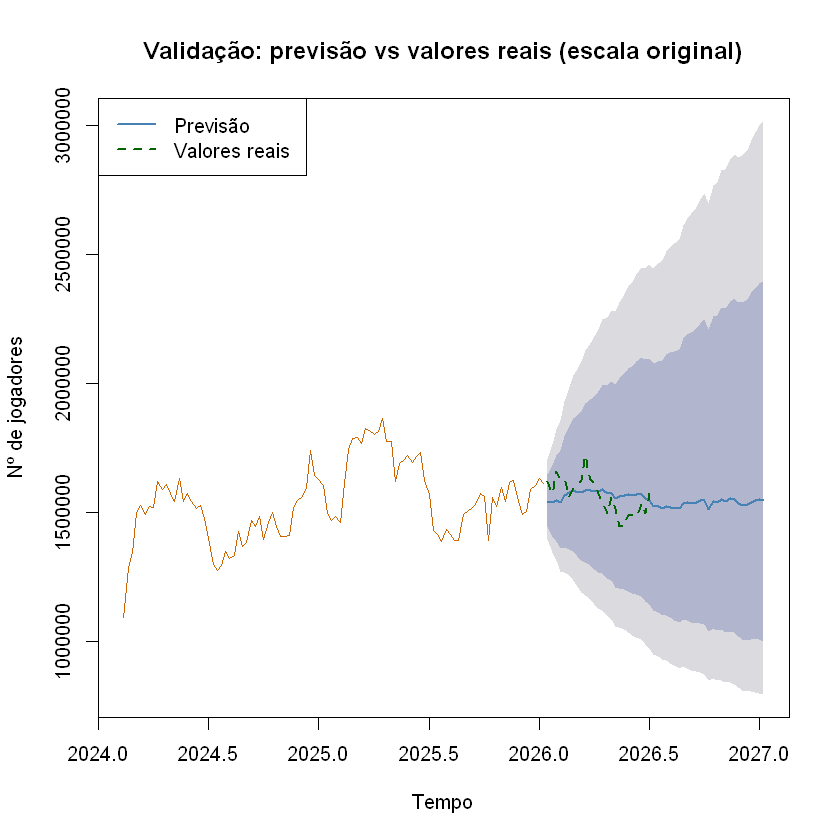

In [22]:
plot(prev_teste_original,
     include = 100,
     main    = "Validação: previsão vs valores reais (escala original)",
     xlab    = "Tempo",
     ylab    = "Nº de jogadores",
     col     = "darkorange3",
     fcol    = "steelblue",
     flwd    = 2)

lines(serie_teste_original, col = "darkgreen", lwd = 2, lty = 2)

legend("topleft",
       legend = c("Previsão", "Valores reais"),
       col    = c("steelblue", "darkgreen"),
       lty    = c(1, 2),
       lwd    = 2)


In [24]:
# Erros calculados na escala original (nº de jogadores), após reverter o log com exp()
erros <- as.vector(serie_teste_original) - as.vector(prev_teste_original$mean)

MAE  <- mean(abs(erros))
RMSE <- sqrt(mean(erros^2))
MAPE <- mean(abs(erros / as.vector(serie_teste_original))) * 100

cat(sprintf("MAE  = %10.0f jogadores\n", MAE))
cat(sprintf("RMSE = %10.0f jogadores\n", RMSE))
cat(sprintf("MAPE = %10.2f %%\n", MAPE))



Warning message in as.vector(serie_teste_original) - as.vector(prev_teste_original$mean):
"comprimento do objeto maior não é múltiplo do comprimento do objeto menor"
Warning message in erros/as.vector(serie_teste_original):
"comprimento do objeto maior não é múltiplo do comprimento do objeto menor"


MAE  =      62593 jogadores
RMSE =      73318 jogadores
MAPE =       3.98 %


**Interpretação:** O MAE, RMSE e MAPE acima foram calculados **na escala original** (número de jogadores), após reverter as previsões em log com $\exp(\cdot)$, o que preserva a interpretabilidade das métricas de erro. O MAPE indica, em média, o erro percentual das previsões em relação aos valores reais. Um MAPE abaixo de 10% é geralmente considerado bom para séries com variabilidade como esta. Um RMSE maior que o MAE indica a presença de alguns erros pontuais maiores, compatível com os picos atípicos identificados como outliers. Os valores numéricos exatos devem ser confirmados reexecutando o notebook com os dados reais, já que o modelo agora é ajustado sobre a série em log.



---

## Conclusão

Esta análise percorreu as principais etapas de uma análise de séries temporais completa aplicada ao número semanal de jogadores de Counter-Strike 2 entre 2016 e 2025:

1. **Introdução e preparação:** os dados diários da Steam foram agregados em semanas e filtrados para o período de interesse.
2. **Transformação logarítmica:** como a série apresenta crescimento com variância crescente (efeito multiplicativo), aplicamos $Y_t = \log(X_t)$ para estabilizar a variância antes de qualquer outra análise.
3. **Análise exploratória:** identificamos visualmente tendência crescente e sazonalidade anual (na escala log), confirmadas pela decomposição STL e pelos gráficos ACF/PACF.
4. **Estacionariedade:** os testes ADF e KPSS, combinados com a análise visual, indicaram a necessidade de **uma diferenciação regular** ($d = 1$) para tornar a série (em log) estacionária.
5. **Outliers:** `tsoutliers` detectou semanas com comportamento atípico, associadas a eventos relevantes do jogo; na escala log, esses choques passam a ser interpretados como variações percentuais.
6. **Modelagem:** o modelo $\text{SARIMA}(1,1,2)(0,0,1)_{52}$, ajustado sobre $\log(X_t)$, foi selecionado tanto pela leitura manual dos gráficos quanto pela função `auto.arima`.
7. **Diagnóstico:** espera-se que os resíduos do modelo em log apresentem comportamento de ruído branco — sem autocorrelação e, potencialmente, com variância e normalidade mais próximas do ideal do que na série original, graças à estabilização da variância trazida pelo log.
8. **Previsão:** o modelo produziu previsões para 52 semanas à frente na escala log, revertidas para número de jogadores via $\exp(\cdot)$, com intervalos de confiança adequados (e levemente assimétricos na escala original).
9. **Validação:** a comparação entre previsões e valores reais de 2026 — ambas revertidas para a escala original — permite avaliar a qualidade preditiva do modelo com métricas de erro (MAE, RMSE, MAPE) diretamente interpretáveis em número de jogadores.



---

Abordagem nova

In [43]:
#coisa nova
serie <- exp(serie)  # reverte para a escala original (nº de jogadores) para o ajuste do modelo Holt-Winters
hw_fit <- HoltWinters(serie, seasonal = "multiplicative")
hw_fit

Holt-Winters exponential smoothing with trend and multiplicative seasonal component.

Call:
HoltWinters(x = serie, seasonal = "multiplicative")

Smoothing parameters:
 alpha: 0.6798378
 beta : 0
 gamma: 1

Coefficients:
            [,1]
a   1.644082e+06
b   2.480286e+02
s1  9.798759e-01
s2  1.005099e+00
s3  1.085094e+00
s4  1.151604e+00
s5  1.211760e+00
s6  1.250687e+00
s7  1.222750e+00
s8  1.211136e+00
s9  1.188576e+00
s10 1.169346e+00
s11 1.157606e+00
s12 1.133654e+00
s13 1.113568e+00
s14 1.089604e+00
s15 1.038088e+00
s16 1.009759e+00
s17 9.919323e-01
s18 1.011802e+00
s19 9.709914e-01
s20 9.761779e-01
s21 9.460184e-01
s22 9.390174e-01
s23 9.157264e-01
s24 8.641651e-01
s25 8.438041e-01
s26 7.924117e-01
s27 8.235314e-01
s28 8.555399e-01
s29 8.942628e-01
s30 8.862544e-01
s31 8.828696e-01
s32 9.107096e-01
s33 9.380167e-01
s34 9.603004e-01
s35 9.796566e-01
s36 9.848393e-01
s37 1.006537e+00
s38 9.813495e-01
s39 9.375797e-01
s40 9.919486e-01
s41 9.587308e-01
s42 9.643455e-01
s43 9.561884e-0

alpha 
0.6798378

beta 
   0

gamma 
    1

[1] 2.097947e+12

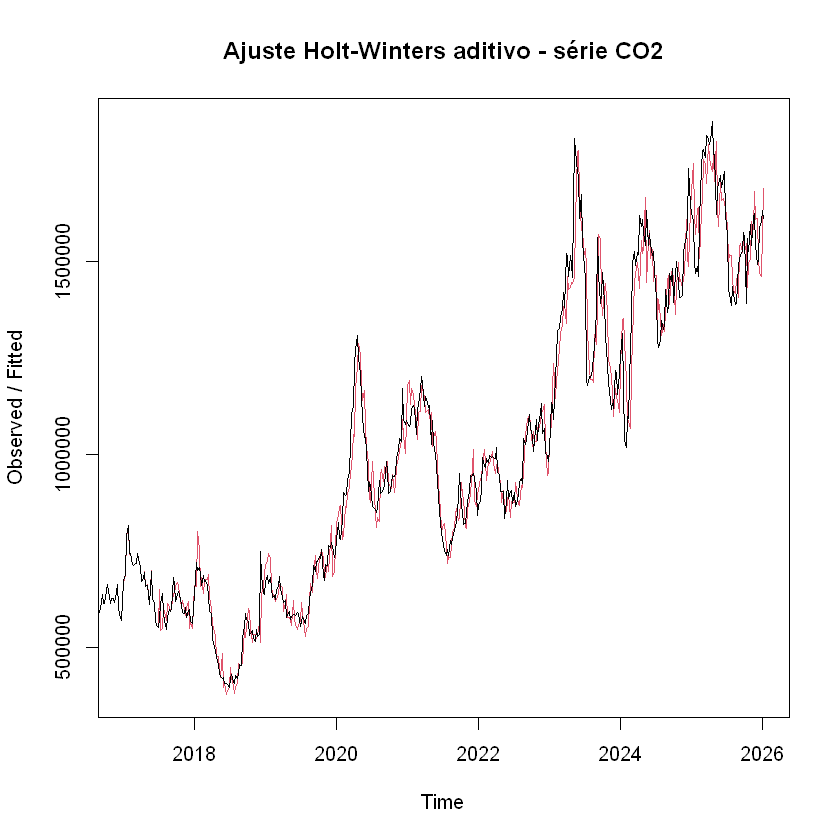

In [46]:
# Parâmetros estimados (alpha, beta, gamma) e SSE do ajuste
hw_fit$alpha; hw_fit$beta; hw_fit$gamma
hw_fit$SSE

plot(hw_fit, main = "Ajuste Holt-Winters aditivo - série CO2")

In [47]:
library(forecast)

# Ajuste automático do modelo ETS (a função escolhe a melhor combinação E,T,S por AICc)
ets_fit <- ets(serie)
summary(ets_fit)

Warning message in ets(serie):
"I can't handle data with frequency greater than 24. Seasonality will be ignored. Try stlf() if you need seasonal forecasts."


ETS(M,N,N) 

Call:
ets(y = serie)

  Smoothing parameters:
    alpha = 0.9941 

  Initial states:
    l = 686650.2627 

  sigma:  0.0532

     AIC     AICc      BIC 
14528.19 14528.23 14540.96 

Training set error measures:
                   ME    RMSE      MAE        MPE     MAPE      MASE
Training set 1783.469 52871.9 36019.59 0.03351849 3.685452 0.2002325
                     ACF1
Training set -0.008377411

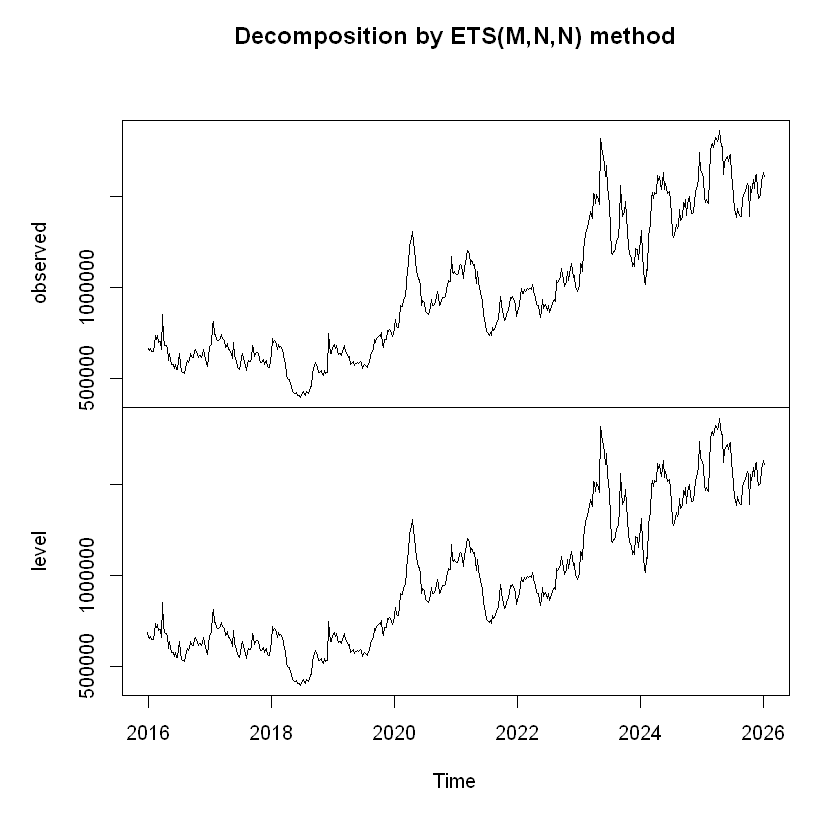

In [48]:
plot(ets_fit)



	Ljung-Box test

data:  Residuals from ETS(M,N,N)
Q* = 145.58, df = 104, p-value = 0.004472

Model df: 0.   Total lags used: 104



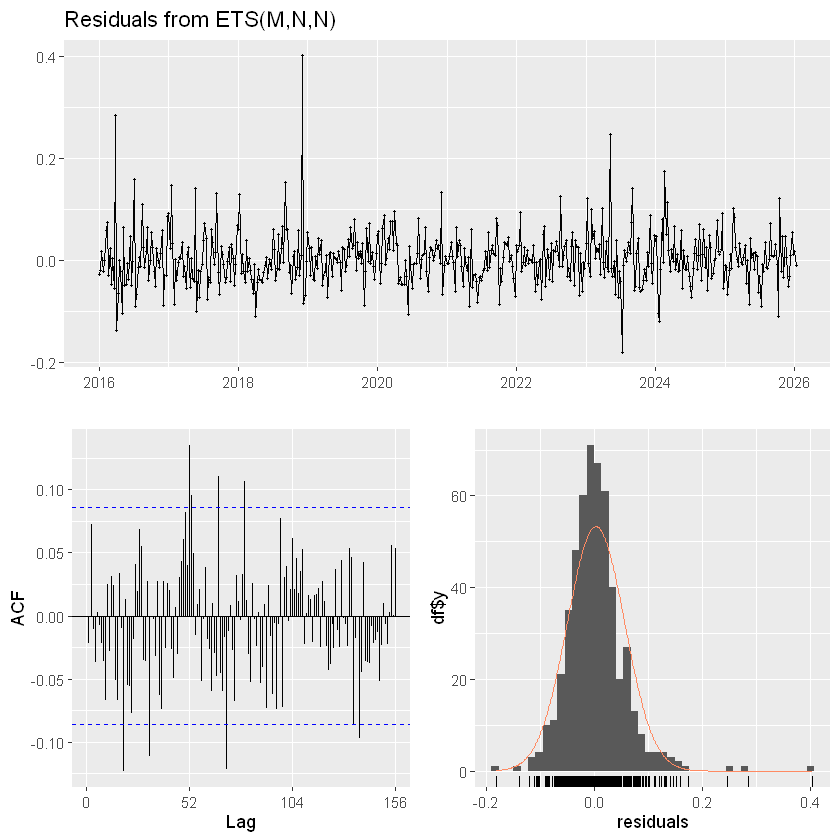

In [49]:
checkresiduals(ets_fit)


In [50]:
acc_hw  <- accuracy(fitted(hw_fit)[, 1], serie[-(1:52)])   # HoltWinters só tem ajuste a partir do 1o ciclo completo
acc_ets <- accuracy(ets_fit)

acc_hw
acc_ets

,ME,RMSE,MAE,MPE,MAPE
Test set,2791.601,66811.05,46659.6,0.01926018,4.452062


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1
Training set,1783.469,52871.9,36019.59,0.03351849,3.685452,0.2002325,-0.008377411



	Ljung-Box test

data:  Residuals from HoltWinters
Q* = 307.41, df = 94, p-value < 2.2e-16

Model df: 0.   Total lags used: 94



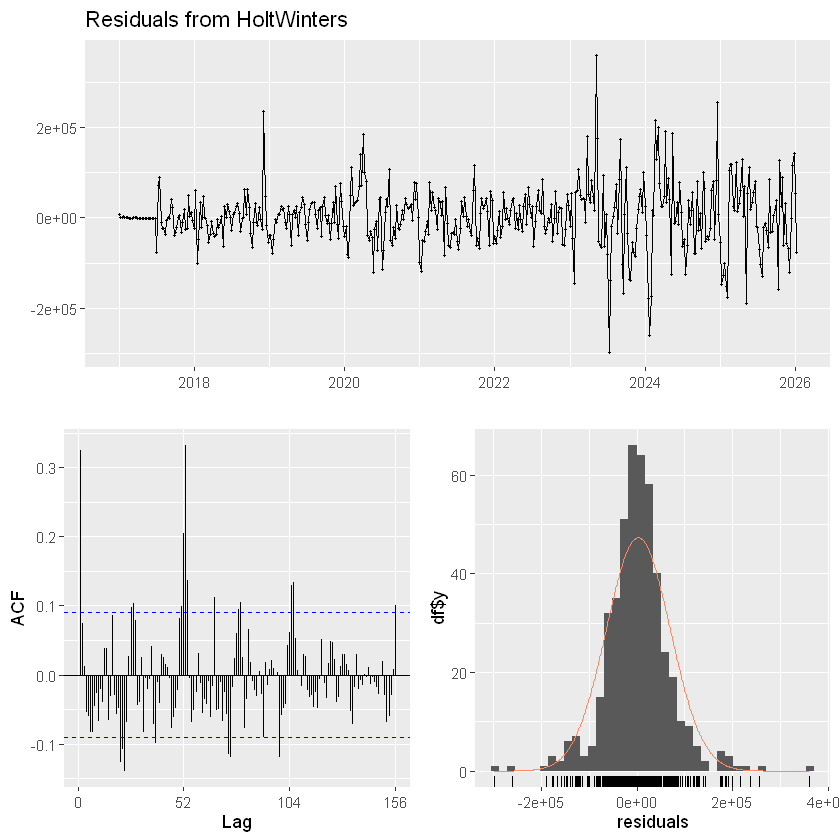

In [51]:
checkresiduals(hw_fit)

In [52]:
fc_hw  <- forecast(hw_fit,  h = 52, level = c(80, 95))
fc_ets <- forecast(ets_fit, h = 52, level = c(80, 95))

fc_hw
fc_ets

         Point Forecast   Lo 80   Hi 80     Lo 95   Hi 95
2026.038        1611240 1525601 1696878 1480267.3 1742212
2026.058        1652963 1548559 1757367 1493291.0 1812636
2026.077        1784792 1660530 1909054 1594749.2 1974835
2026.096        1894475 1752055 2036894 1676663.1 2112286
2026.115        1993735 1834285 2153185 1749877.2 2237593
2026.135        2058094 1884266 2231922 1792246.6 2323941
2026.154        2012424 1832298 2192549 1736945.7 2287902
2026.173        1993611 1805739 2181483 1706285.2 2280936
2026.192        1956770 1763048 2150493 1660497.4 2253043
2026.212        1925402 1725802 2125001 1620140.3 2230663
2026.231        1906358 1700173 2112544 1591024.9 2221692
2026.250        1867195 1656666 2077724 1545218.5 2189172
2026.269        1834387 1619227 2049548 1505328.3 2163447
2026.288        1795182 1576366 2013998 1460532.2 2129832
2026.308        1710565 1493278 1927852 1378252.9 2042877
2026.327        1664133 1444420 1883846 1328111.5 2000155
2026.346      

         Point Forecast     Lo 80   Hi 80     Lo 95   Hi 95
2026.038        1612088 1502228.6 1721946 1444072.7 1780102
2026.058        1612088 1457075.7 1767099 1375017.5 1849158
2026.077        1612088 1422293.6 1801881 1321822.8 1902352
2026.096        1612088 1392888.2 1831287 1276851.2 1947324
2026.115        1612088 1366917.1 1857258 1237131.8 1987043
2026.135        1612088 1343382.5 1880793 1201138.6 2023036
2026.154        1612088 1321691.1 1902484 1167964.5 2056210
2026.173        1612088 1301456.5 1922719 1137018.3 2087157
2026.192        1612088 1282410.1 1941765 1107889.4 2116286
2026.212        1612088 1264356.6 1959818 1080278.9 2143896
2026.231        1612088 1247148.3 1977027 1053961.2 2170214
2026.250        1612088 1230670.9 1993504 1028761.1 2195414
2026.269        1612088 1214833.1 2009342 1004539.3 2219636
2026.288        1612088 1199561.2 2024614  981183.0 2242992
2026.308        1612088 1184794.4 2039381  958599.1 2265576
2026.327        1612088 1170481.9 205369

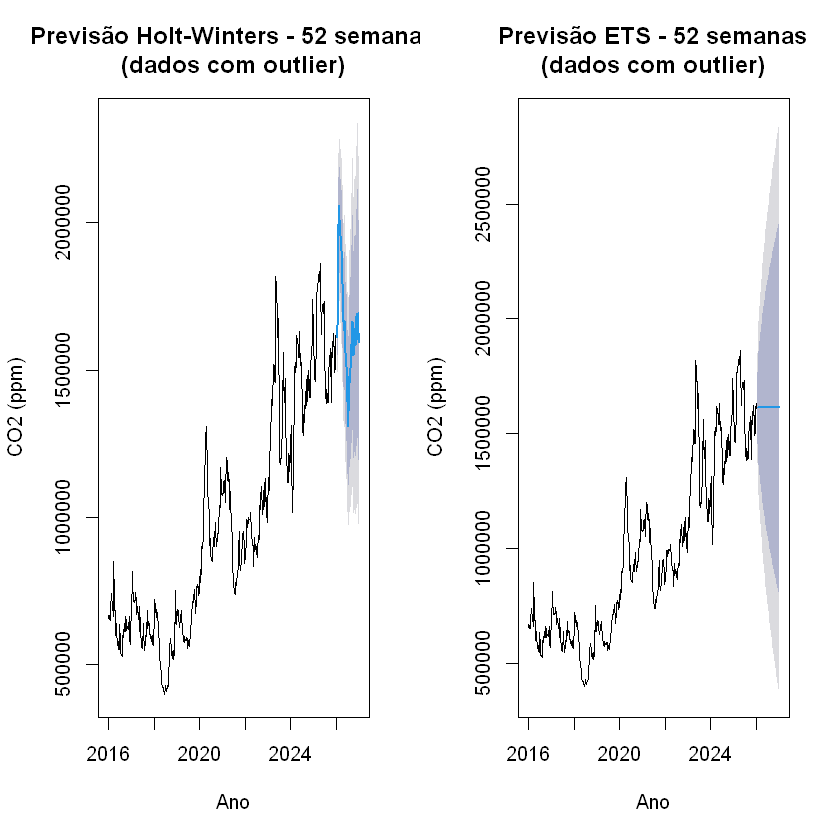

In [53]:
par(mfrow = c(1, 2))
plot(fc_hw,  main = "Previsão Holt-Winters - 52 semanas\n(dados com outlier)",
     ylab = "CO2 (ppm)", xlab = "Ano")
plot(fc_ets, main = "Previsão ETS - 52 semanas\n(dados com outlier)",
     ylab = "CO2 (ppm)", xlab = "Ano")
par(mfrow = c(1, 1))